## Actividad Limpieza de Datos
### Integrantes del equipo:
##### Vera Sofía Acevedo Gómez A01747156
##### Yael Michel García López A01750911

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
# Carga de los datos
df = pd.read_csv("bike_buyers.csv")

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1251 entries, 0 to 1250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1251 non-null   int64  
 1   Marital Status    1244 non-null   object 
 2   Gender            1238 non-null   object 
 3   Income            1243 non-null   object 
 4   Children          1238 non-null   float64
 5   Education         1251 non-null   object 
 6   Occupation        1251 non-null   object 
 7   Home Owner        1247 non-null   object 
 8   Cars              1242 non-null   float64
 9   Commute Distance  1251 non-null   object 
 10  Region            1251 non-null   object 
 11  Age               1238 non-null   float64
 12  Purchased Bike    1251 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 127.2+ KB


In [76]:
df.head(3)

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12591,Married,Female,"30,000",4.0,Graduate Degree,Clerical,Yes,0.0,0-1 Miles,Europe,45.0,No
1,14058,Single,Male,"70,000",0.0,Bachelors,Professional,No,1.0,5-10 Miles,Pacific,41.0,Yes
2,23962,Married,Female,"10,000",0.0,Partial High School,Manual,Yes,2.0,1-2 Miles,Europe,32.0,No


In [77]:
df.describe()

,ID,Children,Cars,Age
count,1251.000000,1238.000000,1242.000000,1238.000000
mean,20030.208633,1.929725,1.479066,44.058966
std,5331.451777,1.638977,1.121885,11.271138
min,11000.000000,0.000000,0.000000,25.000000
25%,15465.000000,0.000000,1.000000,35.000000
50%,19731.000000,2.000000,1.000000,43.000000
75%,24549.000000,3.000000,2.000000,52.000000
max,29447.000000,5.000000,4.000000,89.000000


In [78]:
# Income de object a float
df["Income"] = pd.to_numeric(df["Income"].str.replace(",", ""))

In [79]:
# Pasamos todas las columnas tipo object a minúsculas
columnas = ["Marital Status", "Gender", "Education", "Occupation",
             "Home Owner", "Region", "Commute Distance", "Purchased Bike"]
for col in columnas:
  df[col] = df[col].str.strip().str.lower()

In [80]:
df[df.duplicated()]

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
57,20598,married,male,100000.0,3.0,partial high school,professional,yes,0.0,10+ miles,europe,59.0,yes
98,19562,single,female,60000.0,2.0,bachelors,professional,yes,1.0,2-5 miles,pacific,37.0,yes
116,11270,married,male,130000.0,2.0,graduate degree,management,yes,3.0,0-1 miles,north america,42.0,yes
128,20380,married,female,60000.0,3.0,graduate degree,management,yes,2.0,10+ miles,north america,69.0,no
133,20897,married,female,30000.0,1.0,bachelors,skilled manual,yes,2.0,0-1 miles,europe,40.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,21770,married,male,60000.0,4.0,bachelors,management,yes,2.0,10+ miles,north america,60.0,no
1244,14193,single,female,100000.0,3.0,partial college,management,yes,4.0,10+ miles,europe,56.0,no
1246,19364,married,male,40000.0,1.0,bachelors,skilled manual,yes,0.0,0-1 miles,europe,43.0,yes
1247,26305,single,female,60000.0,2.0,bachelors,skilled manual,no,0.0,0-1 miles,north america,36.0,yes


In [81]:
# Eliminación de duplicados
df = df.drop_duplicates()

In [82]:
df.isna().sum()

ID                   0
Marital Status       7
Gender              11
Income               6
Children             8
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                  8
Purchased Bike       0
dtype: int64

In [83]:
df["Marital Status"].describe()
#df["Income"].plot.box()

count         993
unique          2
top       married
freq          535
Name: Marital Status, dtype: object

In [84]:
df["Income"].nlargest(5)

37     170000.0
421    170000.0
647    170000.0
702    160000.0
730    160000.0
Name: Income, dtype: float64

<Axes: >

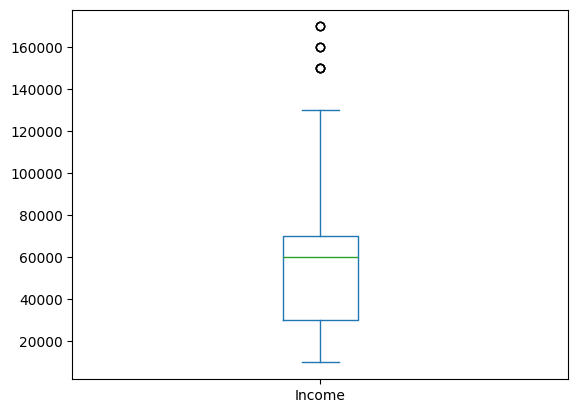

In [85]:
df["Income"].plot.box()


<Axes: ylabel='Frequency'>

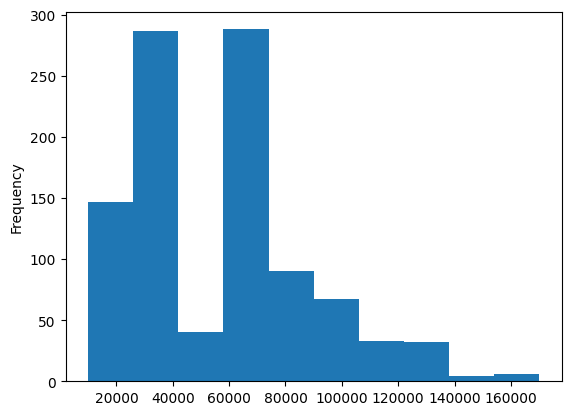

In [86]:
df["Income"].plot.hist()

<Axes: ylabel='Density'>

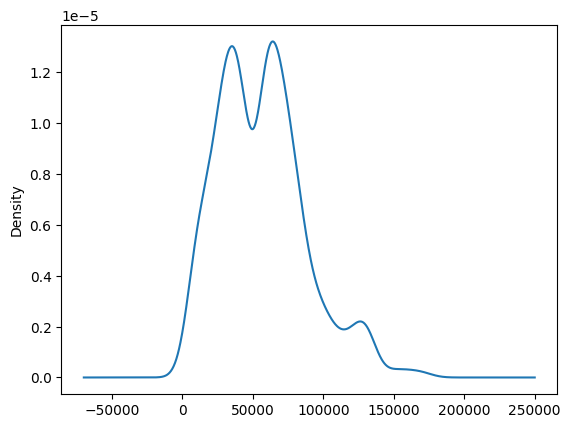

In [87]:
df["Income"].plot.kde()

<Axes: >

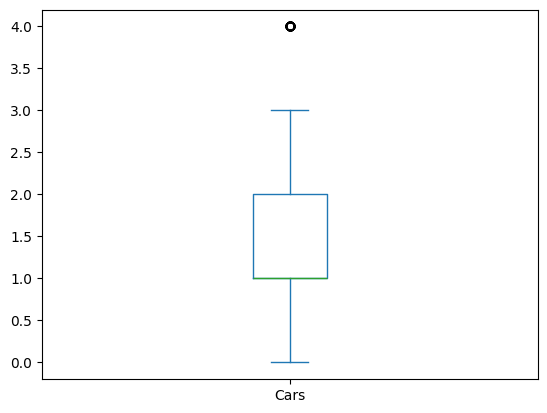

In [88]:
df["Cars"].plot.box()


<Axes: ylabel='Frequency'>

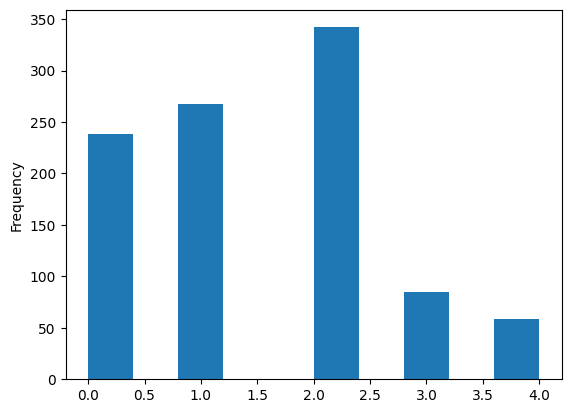

In [89]:
df["Cars"].plot.hist()

<Axes: ylabel='Density'>

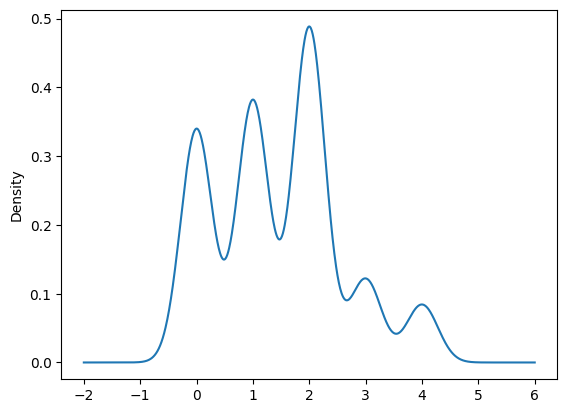

In [90]:
df["Cars"].plot.kde()

<Axes: >

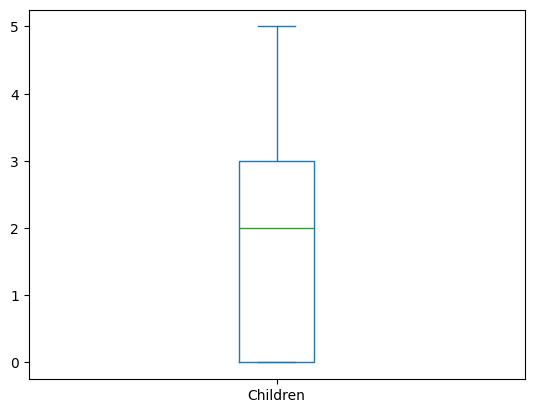

In [91]:
df["Children"].plot.box()


<Axes: ylabel='Frequency'>

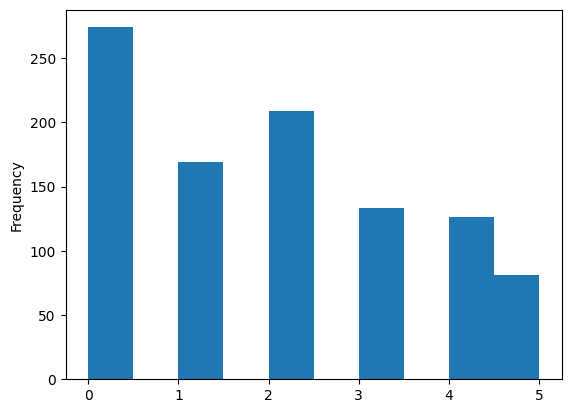

In [92]:
df["Children"].plot.hist()

<Axes: ylabel='Density'>

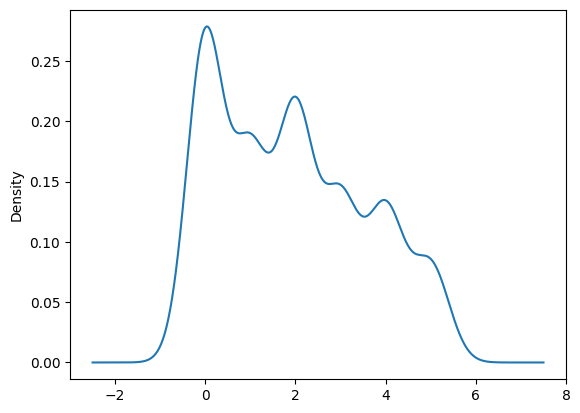

In [93]:
df["Children"].plot.kde()

<Axes: >

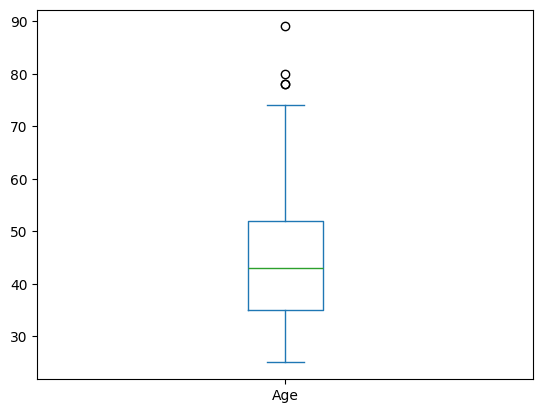

In [94]:
df["Age"].plot.box()


<Axes: ylabel='Frequency'>

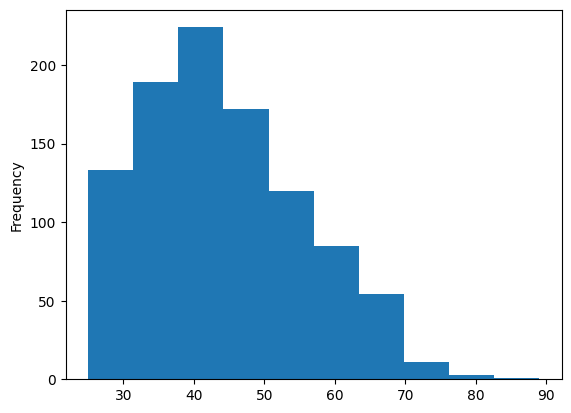

In [95]:
df["Age"].plot.hist()

<Axes: ylabel='Density'>

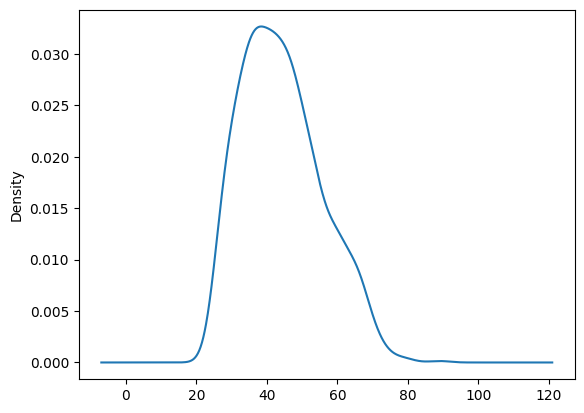

In [96]:
df["Age"].plot.kde()

In [97]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
male      500
female    489
Name: count, dtype: int64


In [98]:
# Imputar datos
# Llenamos los datos faltantes de Marital Status,
# Gender, Home Owner, Cars, Children, Income y Age
# object -> moda
# númericos:
#  -> media -> distribución normal y que no haya muchos valores atípicos
#  -> mediana -> distribución no es normal, si es normal pero cargada a
#     alguno de los extremos, hay muchos valores atípicos o
#     o los valores atípicos están muy alejados del centro
df = df.fillna({
    "Marital Status": df["Marital Status"].mode()[0], 
    "Gender": df["Gender"].mode()[0],
    "Home Owner": df["Home Owner"].mode()[0],
    "Cars": df["Cars"].median(),
    "Children": df["Children"].median(),
    "Income": df["Income"].median(),
    "Age": df["Age"].median()
})

In [99]:
df["Education"].describe()


count          1000
unique            5
top       bachelors
freq            306
Name: Education, dtype: object

In [100]:
df["Education"].value_counts()

Education
bachelors              306
partial college        265
high school            179
graduate degree        174
partial high school     76
Name: count, dtype: int64

In [101]:
df["Occupation"].describe()


count             1000
unique               5
top       professional
freq               276
Name: Occupation, dtype: object

In [102]:
df["Occupation"].value_counts()

Occupation
professional      276
skilled manual    255
clerical          177
management        173
manual            119
Name: count, dtype: int64

In [103]:
df["Region"].value_counts()

Region
north america    508
europe           300
pacific          192
Name: count, dtype: int64

In [104]:
df["Commute Distance"].value_counts()

Commute Distance
0-1 miles     366
5-10 miles    192
1-2 miles     169
2-5 miles     162
10+ miles     111
Name: count, dtype: int64

In [105]:
df.reset_index(drop=True, inplace=True)


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1000 non-null   int64  
 1   Marital Status    1000 non-null   object 
 2   Gender            1000 non-null   object 
 3   Income            1000 non-null   float64
 4   Children          1000 non-null   float64
 5   Education         1000 non-null   object 
 6   Occupation        1000 non-null   object 
 7   Home Owner        1000 non-null   object 
 8   Cars              1000 non-null   float64
 9   Commute Distance  1000 non-null   object 
 10  Region            1000 non-null   object 
 11  Age               1000 non-null   float64
 12  Purchased Bike    1000 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 101.7+ KB


In [107]:
df.isna().sum()

ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64

In [108]:
df.head(5)

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12591,married,female,30000.0,4.0,graduate degree,clerical,yes,0.0,0-1 miles,europe,45.0,no
1,14058,single,male,70000.0,0.0,bachelors,professional,no,1.0,5-10 miles,pacific,41.0,yes
2,23962,married,female,10000.0,0.0,partial high school,manual,yes,2.0,1-2 miles,europe,32.0,no
3,23419,single,female,70000.0,5.0,bachelors,professional,yes,3.0,10+ miles,pacific,39.0,no
4,21940,married,male,90000.0,5.0,graduate degree,professional,yes,0.0,0-1 miles,north america,47.0,yes


In [109]:
df.describe()

,ID,Income,Children,Cars,Age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,19965.992000,56290.000000,1.911000,1.451000,44.172000
std,5347.333948,30975.722678,1.620403,1.117519,11.316912
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15290.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24470.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


In [110]:
print(f'Mediana: {df["Year"].median()}')
print(f'Moda: {df["Year"].mode()}')

KeyError: 'Year'